# Checkpoint 4 — Questão 1
## Logística de emergência após eventos climáticos

**Turma W — Algoritmos e Estruturas de Dados — FIAP**

**Grupo Resiliência** · Identificador `ESPW-RESILIENCIA` · Semente `SEED = 1128587`

| Integrante | RM |
|---|---|
| Kauã Gabriel Moreira E Silva | RM566043 |
| Mariana Silva do Egito Moreira | RM562544 |

A seed é a soma dos RMs dos integrantes (566043 + 562544).
Todo o notebook depende apenas da semente acima: rodando de novo, os mesmos
números aparecem. Para gerar outra instância basta alterar `SEED` em
`src/config.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from IPython.display import Image, display

from src import config
from src.gerar_dados import gerar_grafo, salvar_grafo, carregar_grafo

grafo = gerar_grafo(config.SEED)
salvar_grafo(grafo)

dist, _ = grafo.dijkstra(0)
inalcancaveis = [v for v, d in dist.items() if d == float("inf")]

print(f"seed                : {config.SEED}")
print(f"vertices            : {len(grafo)}  (1 centro + {len(grafo)-1} pontos)")
print(f"arestas             : {grafo.n_arestas}  (grafo completo teria {len(grafo)*(len(grafo)-1)//2})")
print(f"vias bloqueadas     : {sum(1 for *_ , b in grafo.arestas() if b)}")
print(f"pontos inalcancaveis: {inalcancaveis}")
print(f"capacidade do veiculo: {config.CAPACIDADE_VEICULO}")

seed                : 1128587
vertices            : 21  (1 centro + 20 pontos)
arestas             : 43  (grafo completo teria 210)
vias bloqueadas     : 6
pontos inalcancaveis: []
capacidade do veiculo: 120


## Parte A — Construção do problema e escolha das estruturas

A instância tem 21 vértices (1 centro + 20 pontos), mais de 35 conexões com
peso (distância euclidiana) e um subconjunto de vias declaradas indisponíveis.
Ela **não** é um grafo completo, usa cerca de 20% das arestas possíveis.

| Estrutura | Onde | Operação que a justifica |
|---|---|---|
| `dict[int, dict[int, float]]` | lista de adjacência | grafo esparso: `O(V+E)` de memória em vez de `O(V²)`; peso de uma aresta em `O(1)`; laço de Dijkstra visita só vizinhos reais |
| `set[frozenset]` | vias bloqueadas | teste "esta via está interditada?" em `O(1)` médio, sem duplicar a aresta nos dois sentidos e sem apagá-la (ela precisa aparecer na Figura 1) |
| `dataclass(frozen=True)` (tupla nomeada) | `Ponto` | atributos lidos milhares de vezes e nunca alterados; imutabilidade impede que o Greedy corrompa os dados usados depois pela DP; objeto hashável |
| `heap` (`heapq`) | Dijkstra e ranking guloso | a operação dominante é "extrair o menor": `O(log V)` no heap contra `O(V)` na lista |
| `list[list[float]]` | tabela DP | acesso `O(1)` por índice `(i, c)`; a matriz precisa ser retida inteira para a reconstrução e para a Figura 3 |

O parágrafo abaixo mostra os dados brutos.

In [2]:
import pandas as pd

pontos = pd.DataFrame([{
    "id": p.id, "nome": p.nome, "pessoas": p.pessoas, "prioridade": p.prioridade,
    "demanda": p.demanda, "beneficio": p.beneficio,
    "densidade b/d": round(p.beneficio / p.demanda, 3) if p.demanda else None,
    "dist. do CD": round(dist[p.id], 2),
} for p in grafo.pontos.values() if not p.centro])
pontos.sort_values("densidade b/d", ascending=False).head(10)

,id,nome,pessoas,prioridade,demanda,beneficio,densidade b/d,dist. do CD
7,8,Sitio Novo,3678,5,39,205.94,5.281,66.71
16,17,Recanto Azul,1813,5,22,104.25,4.739,108.05
3,4,Centro Sul,1740,4,21,70.51,3.358,38.99
11,12,Vila Encosta,2798,3,30,94.76,3.159,50.92
19,20,Chacara Sul,3265,4,43,130.34,3.031,32.14
12,13,Distrito Oeste,1466,4,21,59.67,2.841,77.49
8,9,Cohab Leste,2490,3,26,64.47,2.480,81.27
2,3,Morro Verde,3395,3,43,101.69,2.365,59.44
13,14,Nova Aurora,2308,2,21,48.69,2.319,71.91
18,19,Porto Velho Bairro,1319,3,20,41.21,2.061,51.74


In [ ]:
arestas = pd.DataFrame(grafo.arestas(), columns=["origem", "destino", "peso", "bloqueada"])
print("total de vias:", len(arestas))
arestas[arestas.bloqueada]

## Parte B — Solução gulosa

Função de prioridade do grupo:

$$ s_i \;=\; \underbrace{\frac{\beta_i \cdot p_i^{\gamma}}{d_i}}_{\text{densidade de benefício}} \;\cdot\; \underbrace{\frac{1}{1 + \lambda\,\delta_i/\bar{\delta}}}_{\text{desconto logístico}}, \qquad \gamma = 1.5,\ \lambda = 0.6 $$

**Por que essa decisão é localmente vantajosa.** O núcleo $\beta_i/d_i$ não foi
escolhido por intuição: o problema de carga é um *knapsack* 0/1
($\max \sum \beta_i x_i$ sujeito a $\sum d_i x_i \le C$) e, na sua relaxação
fracionária, o teorema de Dantzig garante que ordenar por $\beta_i/d_i$ é
**exatamente ótimo**. Logo, a cada passo, escolher o maior $\beta_i/d_i$
maximiza o ganho por unidade de capacidade consumida, a definição formal de
decisão localmente ótima. Os outros dois fatores corrigem o que o knapsack puro
ignora: $p_i^{1.5}$ faz a razão entre prioridade 5 e 1 valer 11,2 em vez de 5
(risco de vida não é linear), e $1/(1+\lambda\delta_i/\bar\delta)$ desconta o
tempo de deslocamento, que é o segundo recurso escasso. A normalização por
$\bar\delta$ deixa o fator adimensional.

Uma regra como `maior_prioridade_primeiro()` ignora completamente o custo de
capacidade: um ponto de prioridade 5 que consome metade do caminhão pode valer
menos que três pontos de prioridade 4 que cabem juntos.

In [ ]:
from src.greedy import ranking_guloso, selecao_gulosa, limite_fracionario, score

CAP = config.CAPACIDADE_VEICULO
ranking = ranking_guloso(grafo)

print(f"{'pos':>3} {'id':>3} {'nome':<20} {'s_i':>8} {'benef':>8} {'dem':>5} {'prio':>5} {'dist':>7}")
for pos, (s, v) in enumerate(ranking[:10], 1):
    p = grafo.pontos[v]
    print(f"{pos:>3} {v:>3} {p.nome:<20} {s:8.2f} {p.beneficio:8.1f} {p.demanda:5d} {p.prioridade:5d} {dist[v]:7.1f}")

sol_greedy = selecao_gulosa(grafo, CAP)
print()
print(sol_greedy)
print("pontos atendidos:", [grafo.pontos[i].nome for i in sol_greedy.selecionados])
print("capacidade ociosa:", sol_greedy.folga)

## Parte C — Programação dinâmica

**Estado.** `DP[i][c]` = maior benefício obtível considerando apenas os `i`
primeiros pontos candidatos com `c` unidades de capacidade livres. São as duas
únicas informações que afetam o futuro: qualquer subconjunto dos primeiros `i`
pontos com a mesma carga é igualmente bom daqui para a frente (subestrutura
ótima).

**Decisão.** Para o ponto `i`: **não atender** (herda `DP[i-1][c]`) ou
**atender**, viável só se `d_i ≤ c`, valendo `β_i + DP[i-1][c-d_i]`. Não existe
atendimento parcial, a demanda mínima torna o problema 0/1.

**Caso-base.** `DP[0][c] = 0` (nenhum ponto considerado) e `DP[i][0] = 0` (sem
capacidade).

**Recorrência.**

$$ DP[i][c] = \begin{cases} DP[i-1][c] & \text{se } d_i > c\\ \max\big(DP[i-1][c],\ \beta_i + DP[i-1][c-d_i]\big) & \text{caso contrário} \end{cases} $$

**Reconstrução.** Partindo de `(N, C)`: se `DP[i][c] ≠ DP[i-1][c]`, o ponto `i`
**só pode** ter entrado — registra-se `i` e vai-se para `(i-1, c-d_i)`; caso
contrário vai-se para `(i-1, c)`. Exatamente `N` passos, `O(N)`.

In [5]:
from src.dynamic_programming import selecao_dp, construir_tabela, reconstruir, mochila_otimizada

sol_dp = selecao_dp(grafo, CAP)
tabela = sol_dp.detalhes["tabela"]
ids = sol_dp.detalhes["ids_candidatos"]
demandas = sol_dp.detalhes["demandas"]

print(sol_dp)
print("pontos atendidos:", [grafo.pontos[i].nome for i in sol_dp.selecionados])
print(f"tabela DP: {len(tabela)} x {len(tabela[0])} = {len(tabela)*len(tabela[0])} celulas")
print("DP[0][*] todos zero? ", all(v == 0 for v in tabela[0]))
print("DP[*][0] todos zero? ", all(l[0] == 0 for l in tabela))
print("DP[N][C] =", tabela[-1][-1], "== beneficio da solucao?", abs(tabela[-1][-1]-sol_dp.beneficio) < 1e-9)

[dp] beneficio=484.01 carga=120/120 (5 pontos) rota=352.0
pontos atendidos: ['Centro Sul', 'Bairro Industrial', 'Sitio Novo', 'Vila Encosta', 'Recanto Azul']
tabela DP: 21 x 121 = 2541 celulas
DP[0][*] todos zero?  True
DP[*][0] todos zero?  True
DP[N][C] = 484.01 == beneficio da solucao? True


In [6]:
# Passo a passo da reconstrucao (as 6 ultimas decisoes)
c = CAP
print(f"{'i':>3} {'ponto':<20} {'c':>4} {'DP[i][c]':>9} {'DP[i-1][c]':>11}  decisao")
for i in range(len(demandas), max(0, len(demandas)-8), -1):
    entrou = tabela[i][c] != tabela[i-1][c]
    print(f"{i:>3} {grafo.pontos[ids[i-1]].nome:<20} {c:>4} {tabela[i][c]:9.2f} {tabela[i-1][c]:11.2f}"
          f"  {'INCLUI (c -> ' + str(c - demandas[i-1]) + ')' if entrou else 'nao inclui'}")
    if entrou:
        c -= demandas[i-1]

  i ponto                   c  DP[i][c]  DP[i-1][c]  decisao
 20 Chacara Sul           120    484.01      484.01  nao inclui
 19 Porto Velho Bairro    120    484.01      484.01  nao inclui
 18 Bela Vista            120    484.01      484.01  nao inclui
 17 Recanto Azul          120    484.01      439.43  INCLUI (c -> 98)
 16 Vila Lagoa             98    379.76      379.76  nao inclui
 15 Campo Belo             98    379.76      379.76  nao inclui
 14 Nova Aurora            98    379.76      379.76  nao inclui
 13 Distrito Oeste         98    379.76      379.76  nao inclui


In [7]:
# versao O(C) de memoria: mesmo valor otimo, sem possibilidade de reconstrucao
beneficios = sol_dp.detalhes["beneficios"]
print("tabela completa :", tabela[-1][CAP])
print("linha unica O(C):", mochila_otimizada(demandas, beneficios, CAP))
print("celulas guardadas:", len(tabela)*len(tabela[0]), "vs", CAP+1)

tabela completa : 484.01
linha unica O(C): 484.01
celulas guardadas: 2541 vs 121


## Parte D — Greedy × Programação Dinâmica

In [8]:
from src.comparacao import comparar, varredura_capacidades, resumo_varredura

r = comparar(grafo, CAP)
print(f"Greedy : {r['greedy'].beneficio:8.2f}  carga {r['greedy'].carga}/{CAP}  "
      f"({len(r['greedy'].selecionados)} pontos)  t={r['tempo_greedy_s']*1000:.2f} ms")
print(f"DP     : {r['dp'].beneficio:8.2f}  carga {r['dp'].carga}/{CAP}  "
      f"({len(r['dp'].selecionados)} pontos)  t={r['tempo_dp_s']*1000:.2f} ms")
print(f"gap    : {r['gap_absoluto']:+.2f} ({r['gap_percentual']:.2f}%)")
print(f"limite fracionario (Dantzig): {r['limite_fracionario']:.2f}  <- cota superior teorica")

Greedy :   463.88  carga 119/120  (6 pontos)  t=0.37 ms
DP     :   484.01  carga 120/120  (5 pontos)  t=0.47 ms
gap    : +20.13 (4.16%)
limite fracionario (Dantzig): 499.71  <- cota superior teorica


In [9]:
resultados = varredura_capacidades(grafo, 20, 200, 5)
resumo = resumo_varredura(resultados)
for k, v in resumo.items():
    print(f"{k:>22}: {v}")

df = pd.DataFrame([{ "capacidade": x["capacidade"], "greedy": x["greedy"].beneficio,
                     "dp": x["dp"].beneficio, "gap_%": x["gap_percentual"],
                     "greedy_otimo": x["greedy_otimo"] } for x in resultados])
df.head(12)

         n_capacidades: 37
       greedy_otimo_em: 21
      percentual_otimo: 56.76
         gap_medio_pct: 2.0908
        gap_maximo_pct: 35.1128
  capacidade_pior_caso: 20


,capacidade,greedy,dp,gap_%,greedy_otimo
0,20,26.74,41.21,35.1128,False
1,25,104.25,104.25,0.0000,True
2,30,112.80,112.80,0.0000,True
3,35,122.44,122.44,0.0000,True
4,40,205.94,205.94,0.0000,True
5,45,211.26,211.26,0.0000,True
6,50,224.13,224.13,0.0000,True
7,55,229.45,229.45,0.0000,True
8,60,276.45,276.45,0.0000,True
9,65,310.19,310.19,0.0000,True


### Quando o guloso acerta e quando erra

* **Guloso ótimo:** capacidades em que a soma das demandas dos itens de maior
  densidade "fecha" quase exatamente a capacidade (não sobra buraco), e
  capacidades muito grandes, em que quase tudo cabe e a ordem deixa de importar.
* **Guloso subótimo:** capacidades intermediárias. O item de maior densidade
  ocupa espaço e deixa um resíduo que nenhum item seguinte preenche, o guloso
  não revisa a decisão já tomada.
* **DP superior:** sempre que existe uma troca "1 item grande → 2 itens médios"
  que o guloso não enxerga.

### Contraexemplo construído pelo grupo

| ponto | demanda | benefício | densidade |
|---|---|---|---|
| A | 6 | 12,0 | **2,00** |
| B | 5 | 9,5 | 1,90 |
| C | 5 | 9,5 | 1,90 |

Capacidade `C = 10`, todos com prioridade 3 e a mesma distância do centro (os
fatores de prioridade e distância se cancelam e `s_i` vira exatamente
`β_i/d_i`).

In [10]:
from src.comparacao import relatorio_contraexemplo

rel = relatorio_contraexemplo()
print(f"Greedy: {rel['greedy_pontos']} -> beneficio {rel['greedy_beneficio']} "
      f"(carga {rel['greedy_carga']}/{rel['capacidade']}, {rel['capacidade']-rel['greedy_carga']} unidades ociosas)")
print(f"DP    : {rel['dp_pontos']} -> beneficio {rel['dp_beneficio']} "
      f"(carga {rel['dp_carga']}/{rel['capacidade']})")
print(f"perda do guloso: {rel['perda_percentual']}%")

Greedy: ['A'] -> beneficio 12.0 (carga 6/10, 4 unidades ociosas)
DP    : ['B', 'C'] -> beneficio 19.0 (carga 10/10)
perda do guloso: 36.84%


**Por que o guloso falha aqui.** A densidade é o critério ótimo do knapsack
*fracionário*: nele, as 4 unidades que sobram depois de A seriam preenchidas com
80% de B, totalizando 12 + 7,6 = 19,6. No problema 0/1 esse preenchimento é
proibido, então o item de maior densidade abre um **buraco de capacidade** que
nenhuma decisão futura aproveita. A DP considera explicitamente o estado
"capacidade 10 sem o item A" e descobre que {B, C} fecha a carga exata,
rendendo 19,0 contra 12,0 ; 36,8% a mais.

## Parte E — Visualizações

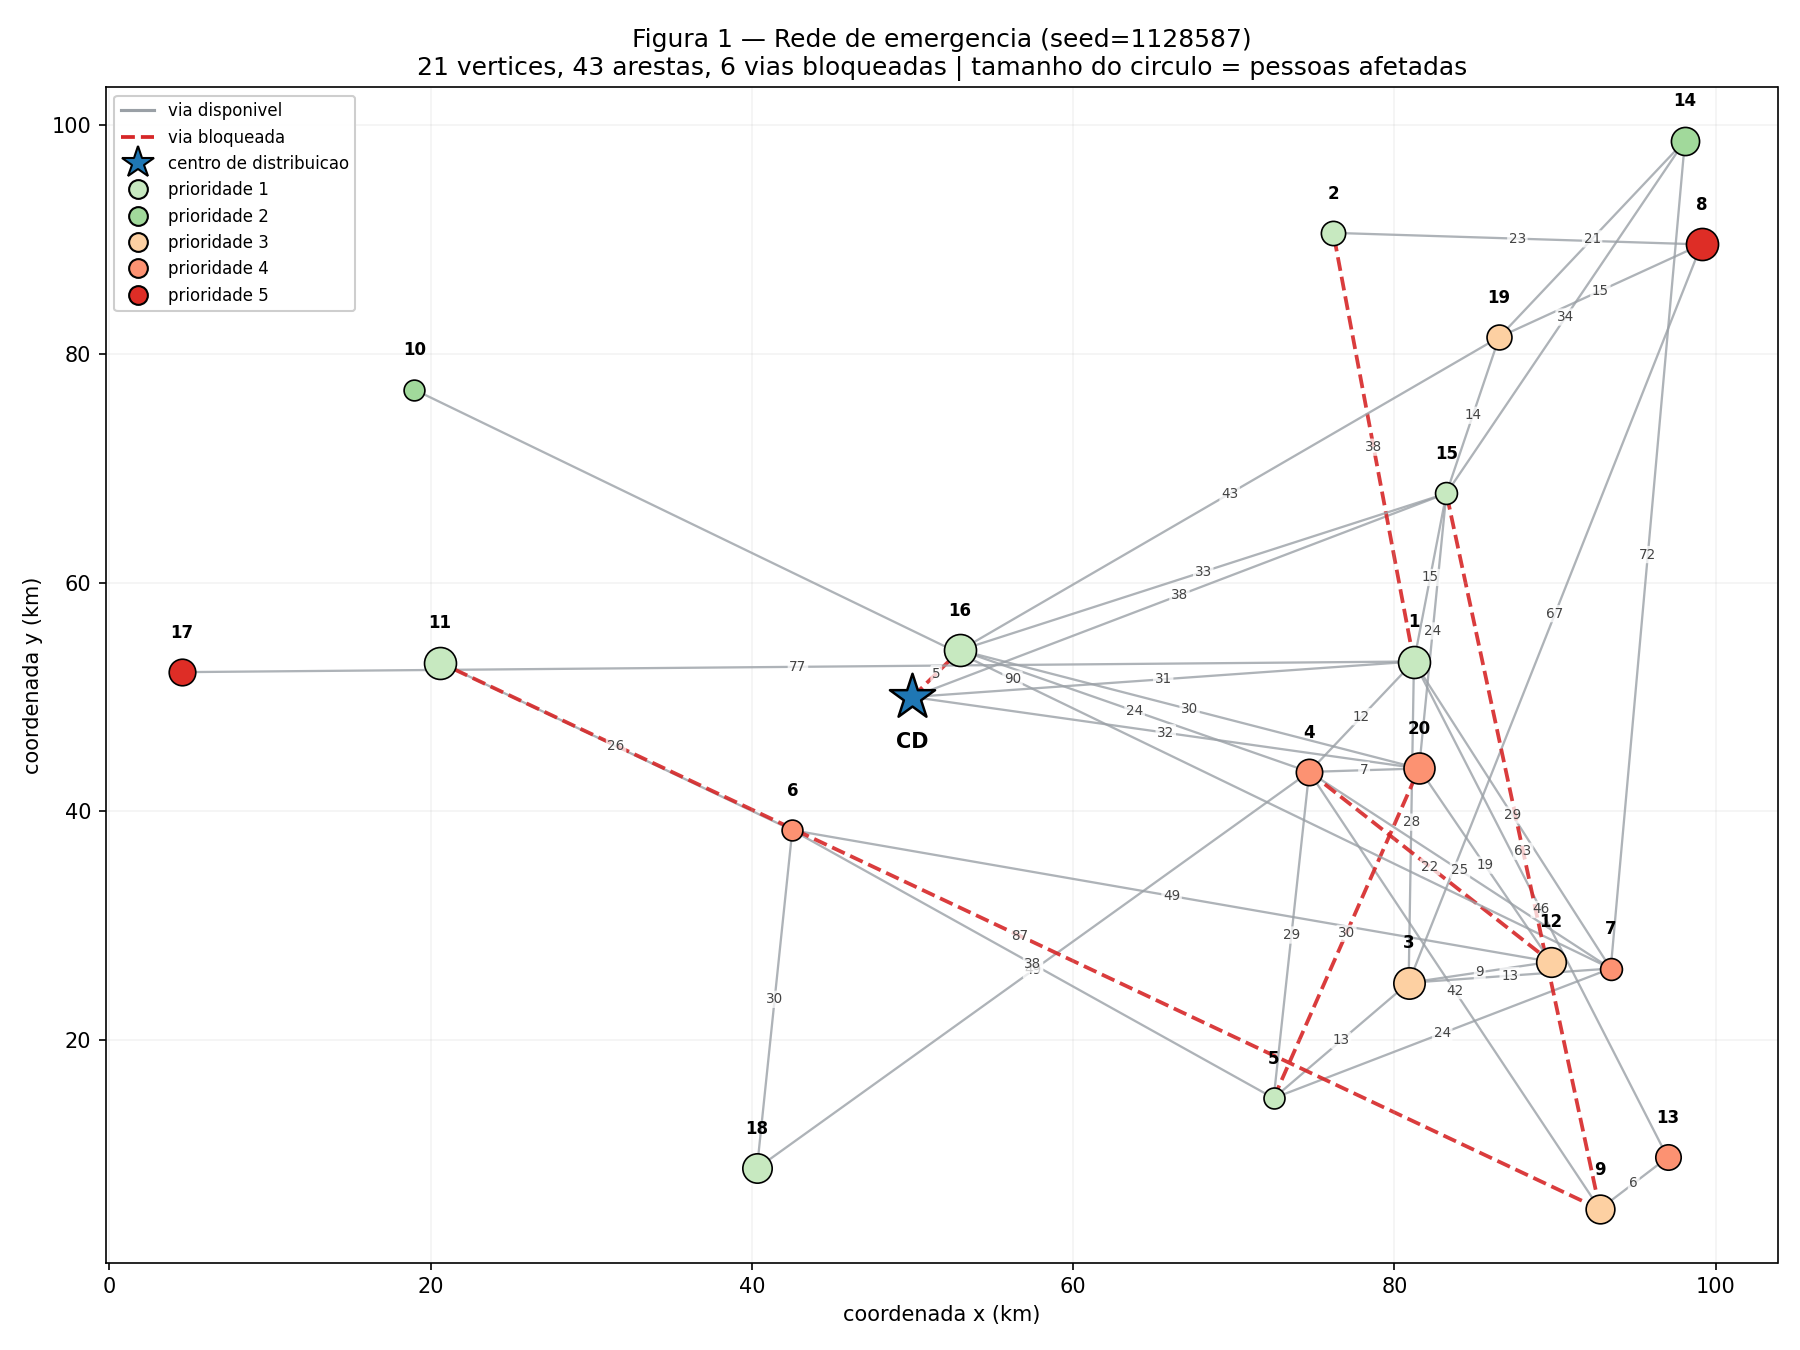

In [11]:
from src.visualizacao_q1 import figura_grafo, figura_solucao, figura_dp, figura_comparacao

f1 = figura_grafo(grafo)
f2g = figura_solucao(grafo, sol_greedy)
f2d = figura_solucao(grafo, sol_dp)
f3 = figura_dp(grafo, sol_dp)
f4 = figura_comparacao(resultados)
display(Image(f1))

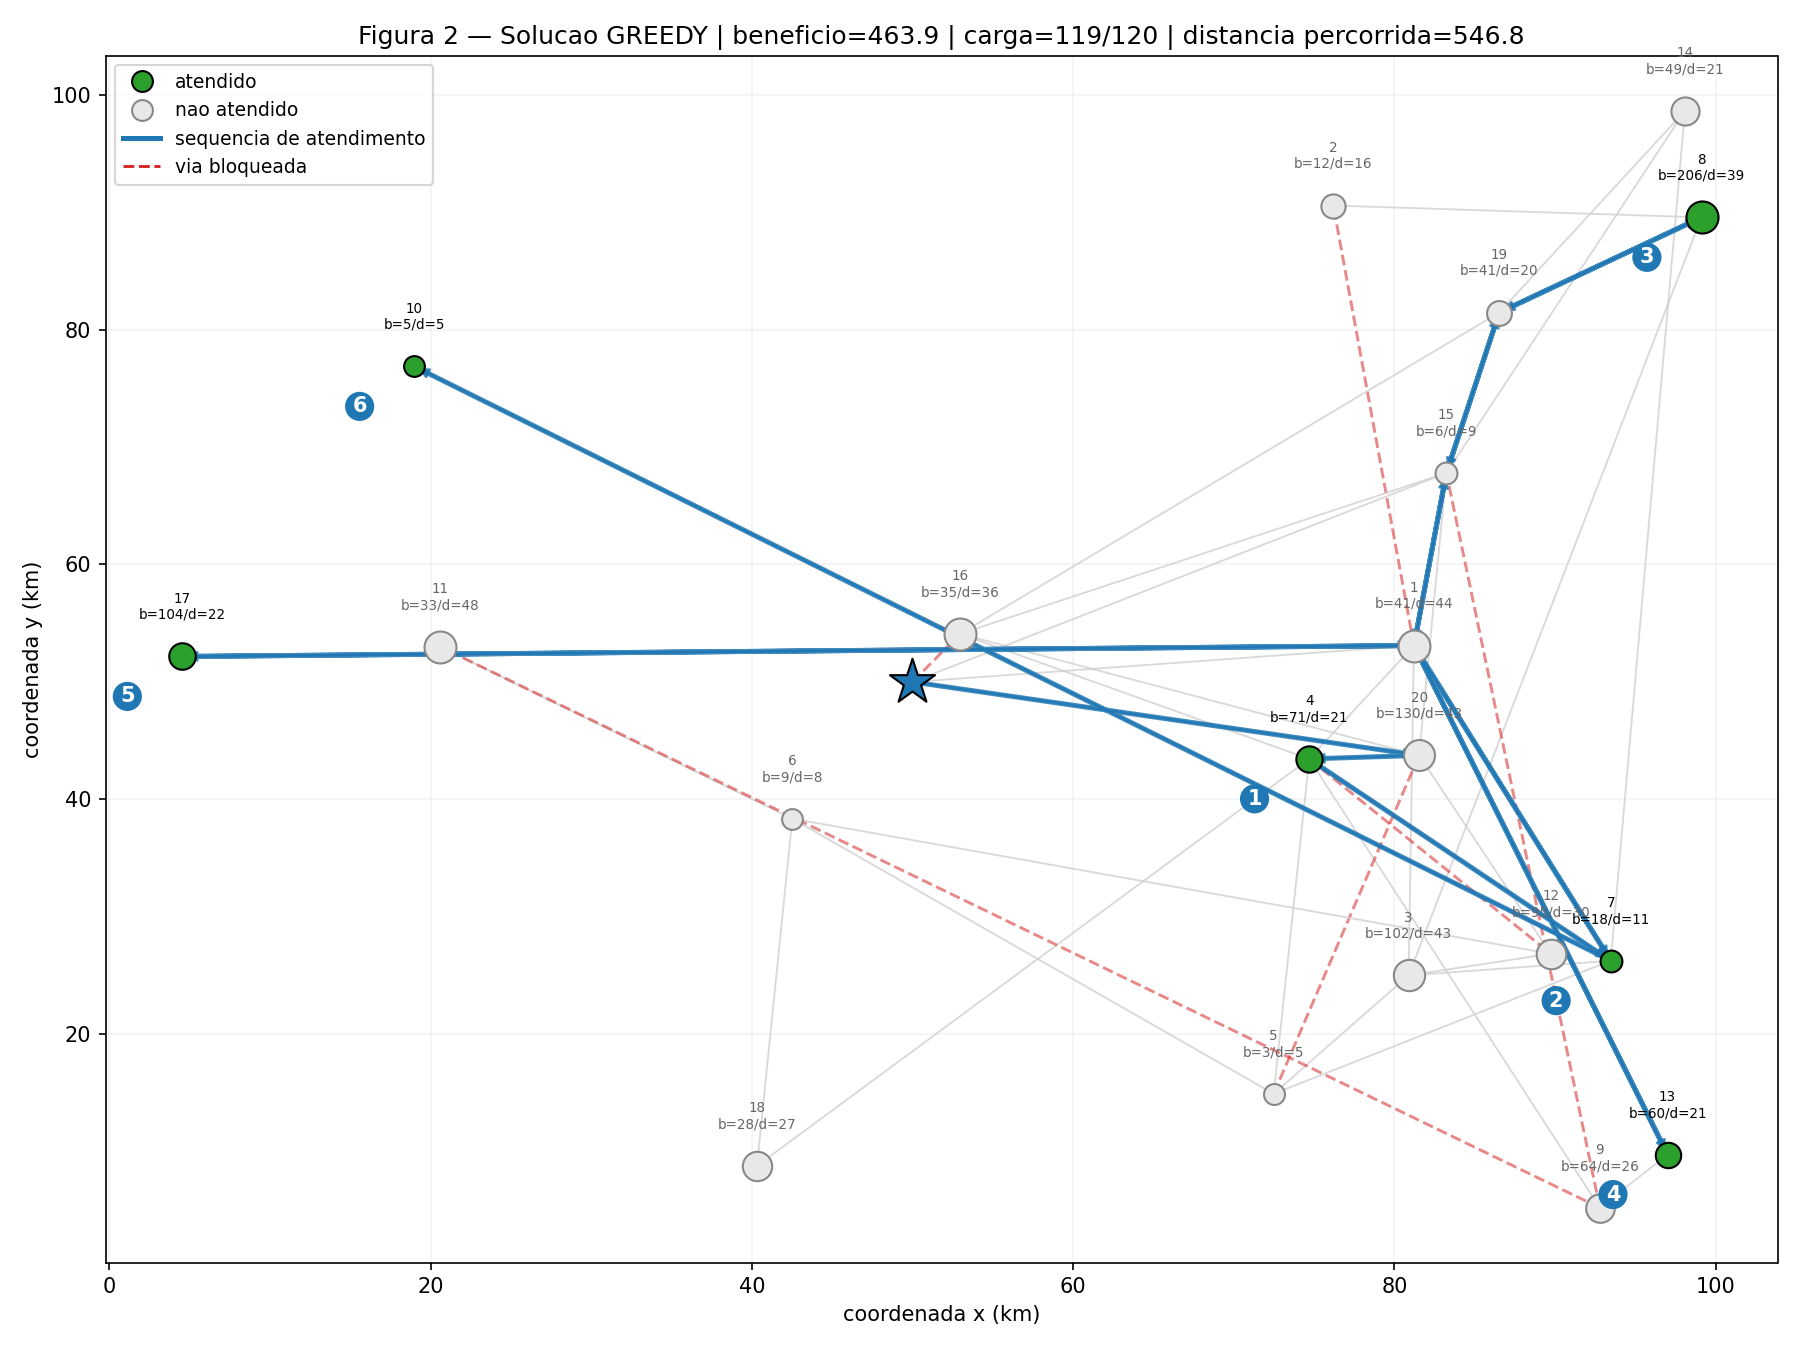

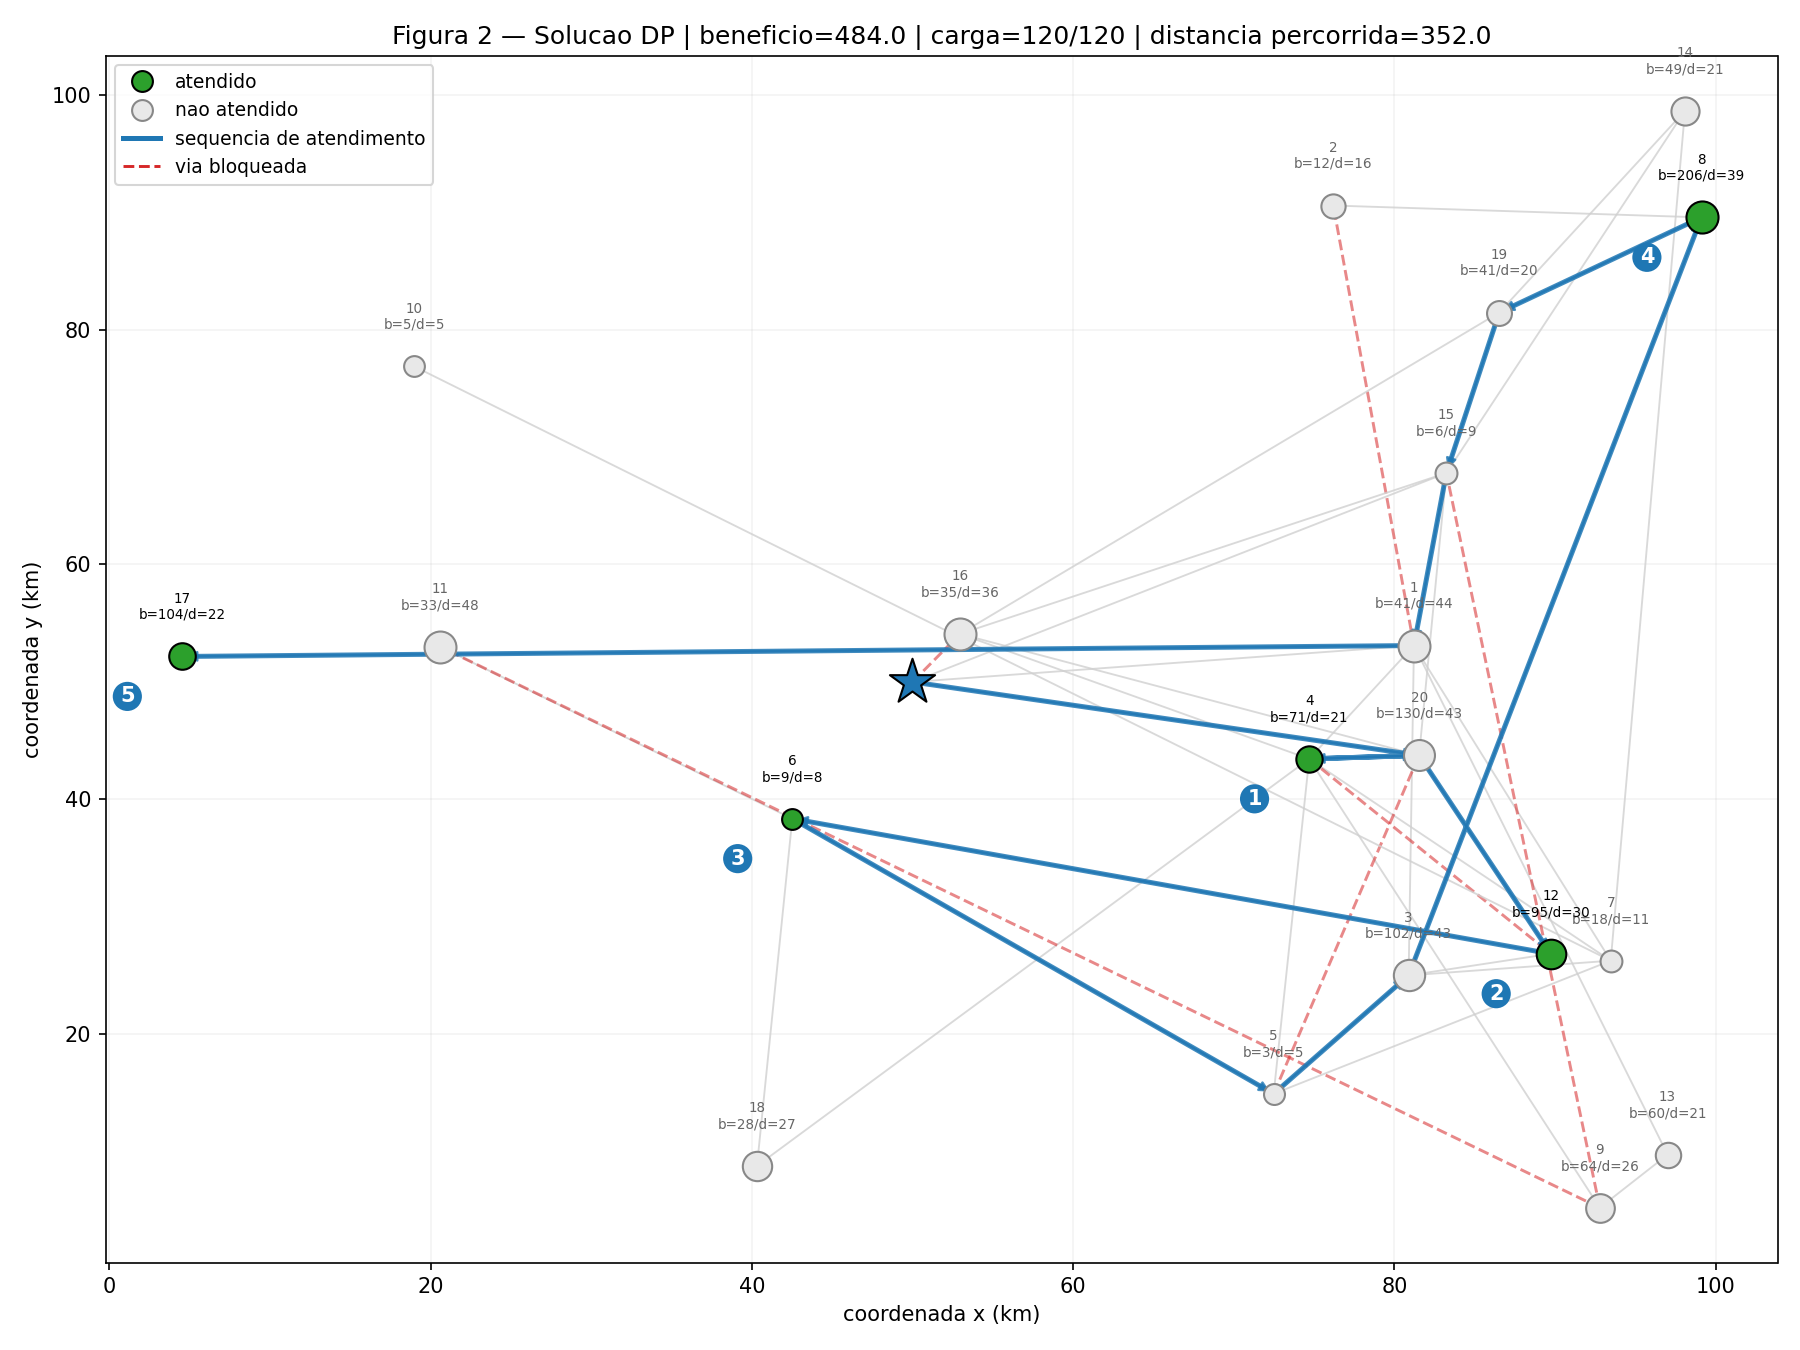

In [12]:
display(Image(f2g))
display(Image(f2d))

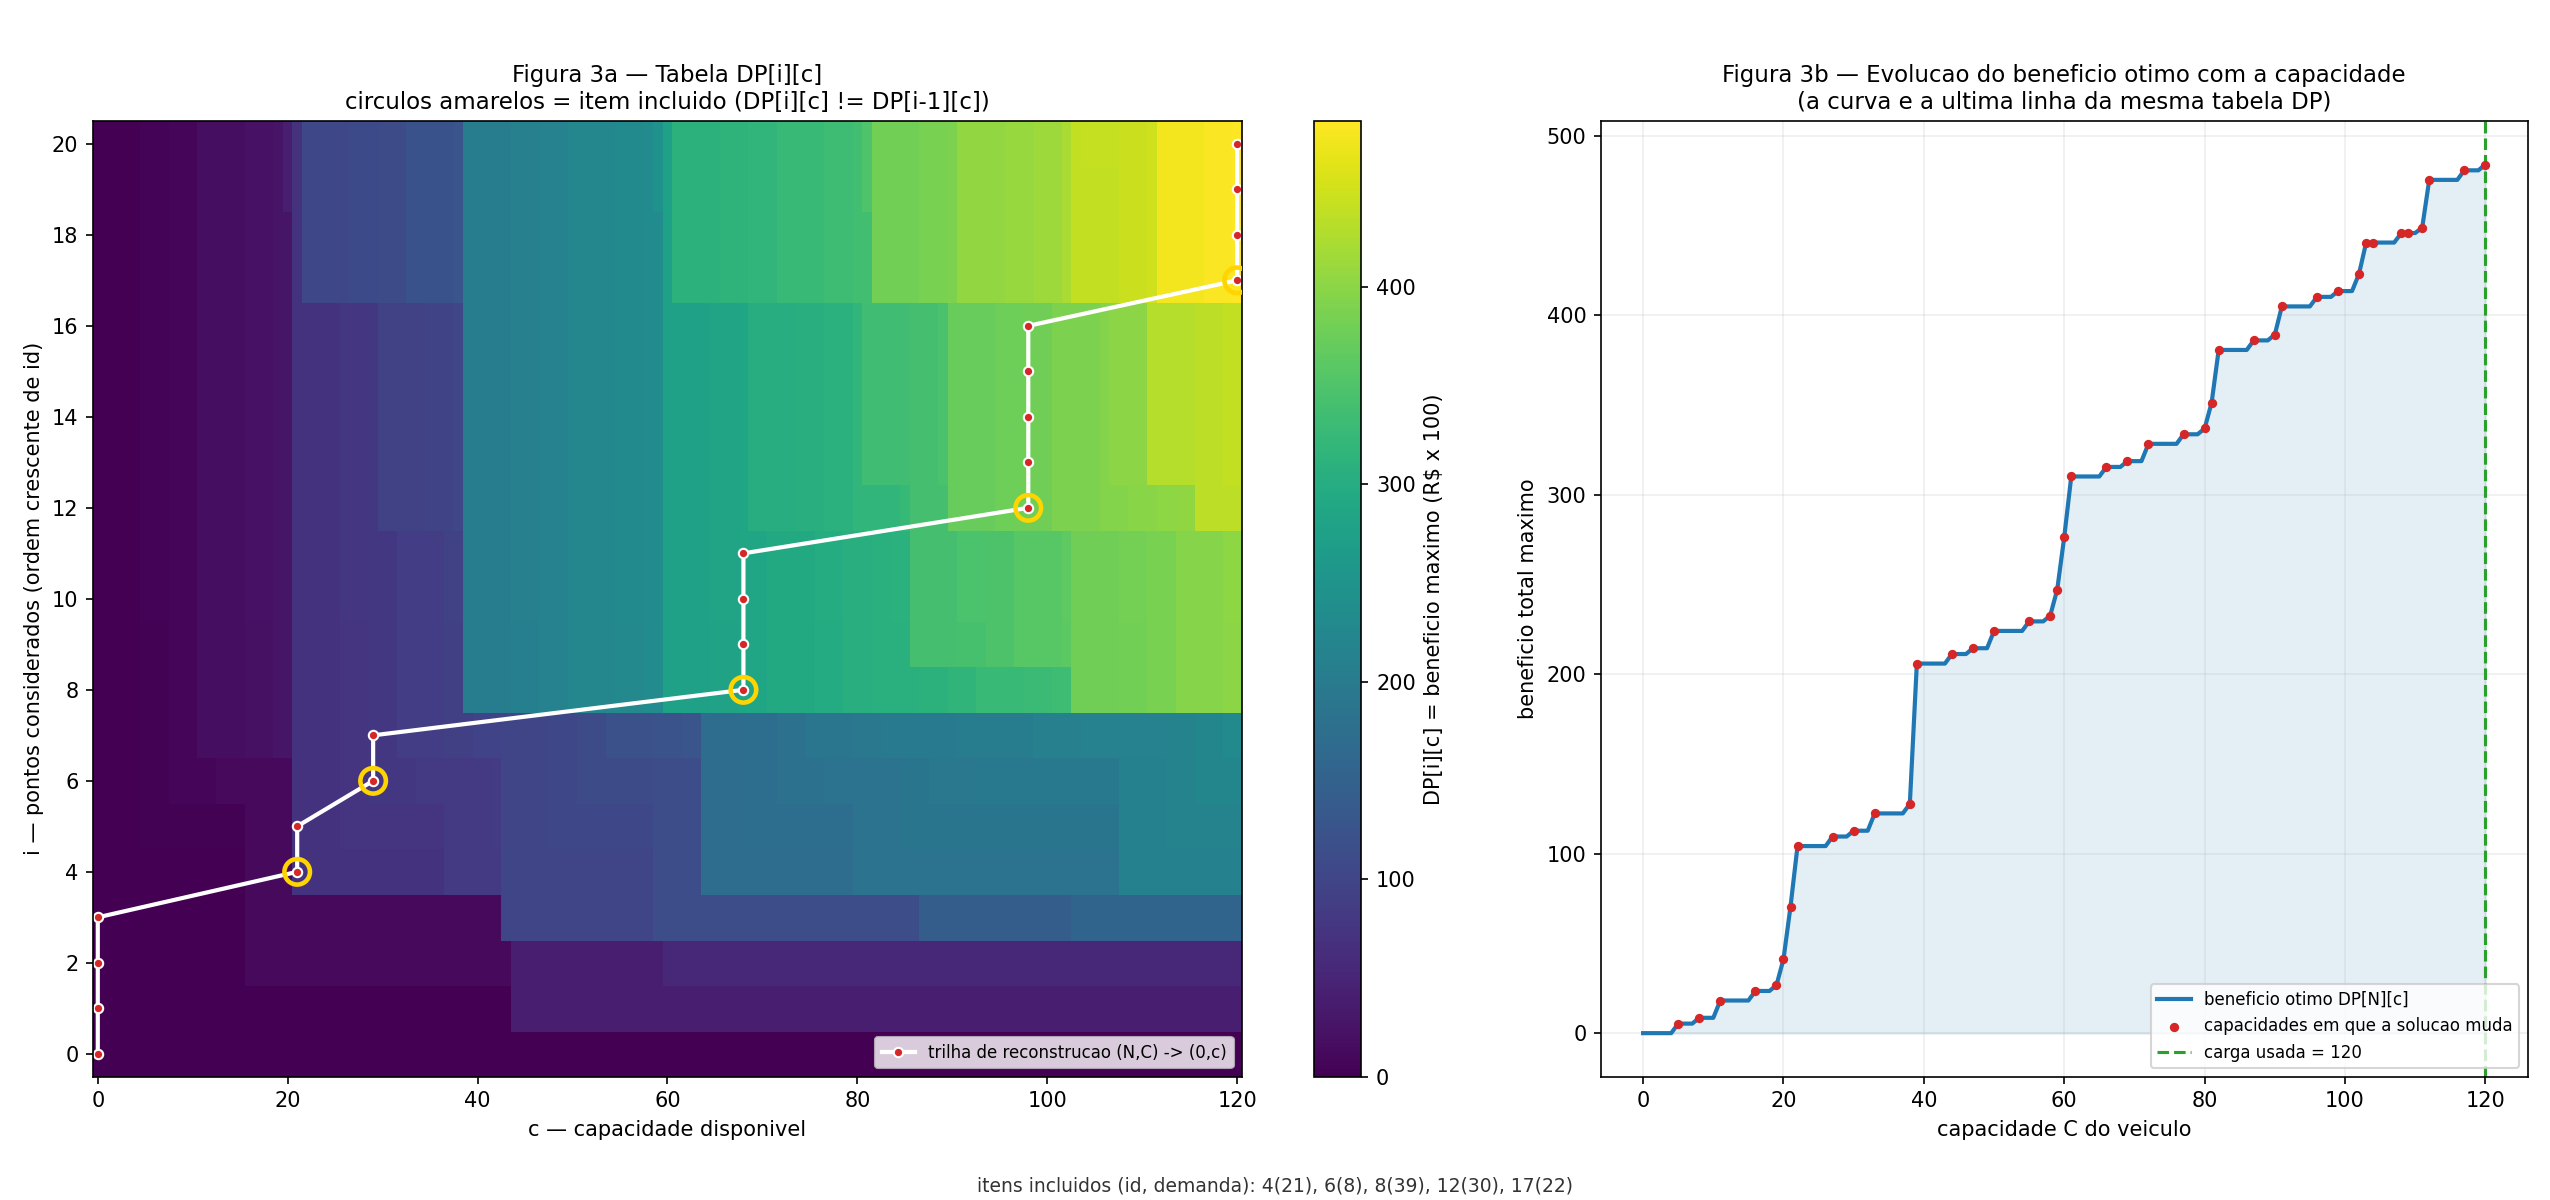

In [13]:
display(Image(f3))

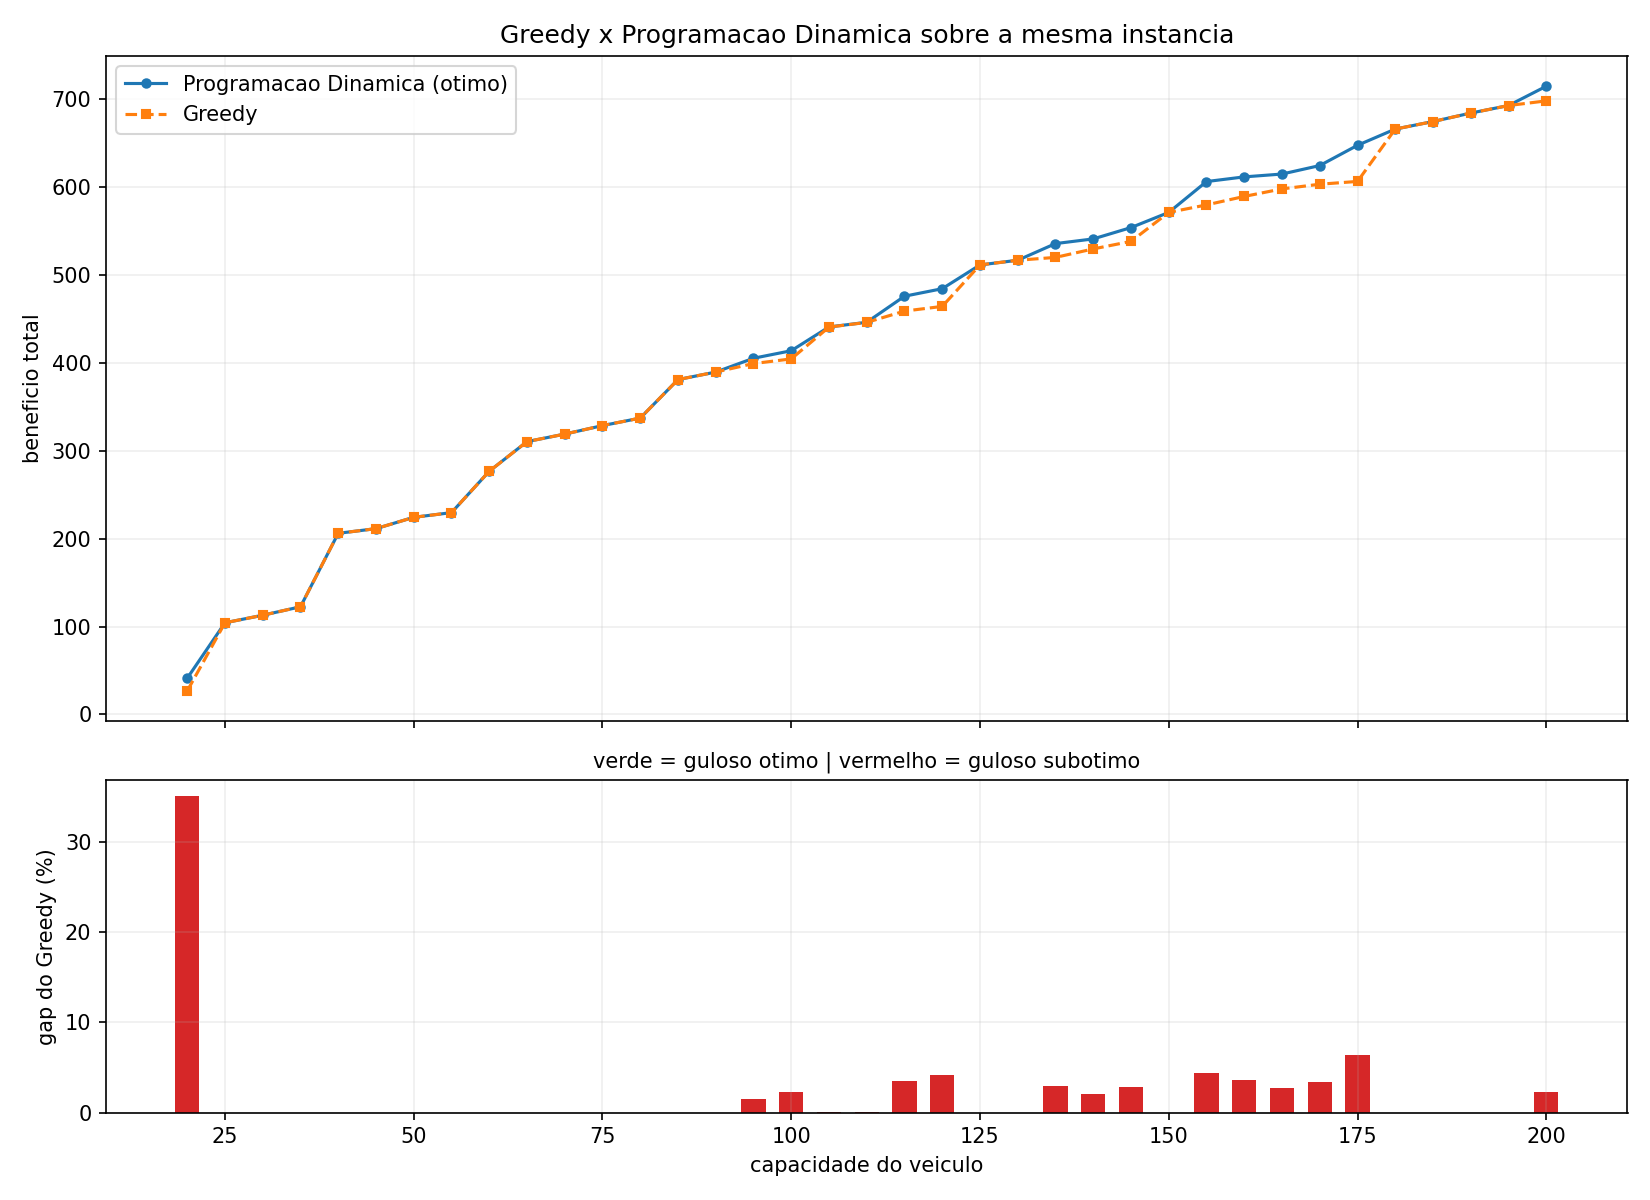

In [14]:
display(Image(f4))

## Parte F — Complexidade

Parâmetros: $V$ = vértices (21), $E$ = arestas (43), $N$ = regiões candidatas,
$C$ = capacidade, $k$ = pontos selecionados.

**Dijkstra.** Cada vértice entra e sai do heap no máximo uma vez por relaxação
bem-sucedida; há no máximo $E$ relaxações, cada `push`/`pop` custa
$O(\log V)$. Somando as inicializações: $T = O((V+E)\log V)$,
$S = O(V+E)$ (adjacência + heap + vetores `dist`/`anterior`).

**Greedy.** Um Dijkstra + cálculo de $s_i$ para $N$ pontos ($O(N)$) +
`heapify` $O(N)$ + $N$ extrações $O(\log N)$ + varredura única da seleção
$O(N)$. Total $T = O((V+E)\log V + N\log N)$, $S = O(V+E+N)$.

**DP.** Dois laços aninhados sobre $N$ linhas e $C+1$ colunas, com trabalho
$O(1)$ por célula: $T = \Theta(N\cdot C)$. A tabela completa custa
$S = \Theta(N\cdot C)$; a versão de linha única custa $S = \Theta(C)$, mas
perde a reconstrução. Reconstrução: $O(N)$. Atenção: $\Theta(N \cdot C)$ é
*pseudopolinomial*, cresce com o **valor** de $C$, não com o número de bits
usados para representá-lo.

**Rota (vizinho mais próximo).** $k$ Dijkstras + $k$ buscas de mínimo:
$O(k(V+E)\log V + k^2)$.

In [15]:
import time
from src.dynamic_programming import construir_tabela

print(f"{'N':>4} {'C':>5} {'N*C':>9} {'tempo (ms)':>11} {'ms por 1e6 celulas':>20}")
for N, C in [(10, 120), (20, 120), (20, 240), (20, 480), (20, 960)]:
    d = [grafo.pontos[i].demanda for i in list(grafo.pontos)[1:N+1]]
    b = [grafo.pontos[i].beneficio for i in list(grafo.pontos)[1:N+1]]
    t0 = time.perf_counter()
    construir_tabela(d, b, C)
    dt = (time.perf_counter() - t0) * 1000
    print(f"{N:>4} {C:>5} {N*C:>9} {dt:11.2f} {dt/(N*C)*1e6:20.1f}")
print()
print("Dobrar C dobra o tempo; dobrar N dobra o tempo -> confirma Theta(N*C).")

   N     C       N*C  tempo (ms)   ms por 1e6 celulas
  10   120      1200        0.07                 60.9
  20   120      2400        0.12                 51.3
  20   240      4800        0.26                 54.9
  20   480      9600        0.75                 78.6
  20   960     19200        1.23                 64.0

Dobrar C dobra o tempo; dobrar N dobra o tempo -> confirma Theta(N*C).


## Conclusões da Questão 1

1. A DP entrega o ótimo garantido; o Greedy fica dentro de poucos por cento na
   maior parte das capacidades, mas pode perder mais de 12% no pior caso desta
   instância, e 36,8% no contraexemplo construído.
2. O custo dessa garantia é memória: $\Theta(N\cdot C)$ contra $O(N)$ do guloso.
   Para $N = 20$ e $C = 120$ isso é irrelevante (2.541 células); para uma frota
   com capacidade na casa dos milhões de unidades, deixaria de ser.
3. As vias bloqueadas alteram o **conjunto de candidatos**, não apenas os pesos:
   um ponto isolado sai da mochila antes de qualquer decisão de carga.